# Badanie Efektywności Reprezentacji Ortogonalnej Sygnałów 1D

---


## 1. Założenia Badawcze (Metoda Monte Carlo)
W tej części projektu odchodzimy od statycznego progu kompresji na rzecz badania **kosztu reprezentacji** sygnału. 
* **Próba:** Przeprowadzamy testy na $N=100$ niezależnych realizacjach dla każdej z 3 klas sygnałów (**APRBS**, **Multisine**, **Filtered Noise**).
* **Cel:** Wyznaczenie współczynnika $K$ – minimalnej liczby współczynników ortogonalnych niezbędnych do odtworzenia sygnału z zachowaniem **95% jego całkowitej energii**.
* **Hipoteza:** Wartość $K$ będzie zmienną losową zależną od charakterystyki sygnału. Spodziewamy się najniższych średnich wartości dla klasy *Multisine* (sygnały rzadkie w dziedzinie częstotliwości) i najwyższych dla *APRBS* (sygnały szerokopasmowe).



---

## 2. Podstawy Teoretyczne

### 2.1. Transformata Fouriera (Analiza)
Dyskretna Transformata Fouriera (DFT) pozwala na dekompozycję sygnału z dziedziny czasu na sumę ortogonalnych funkcji bazowych (zespolonych wykładniczych/sinusoidalnych).



Wzór na współczynniki widmowe:
$$X[k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-j \frac{2\pi}{N} kn}$$

Każdy współczynnik $X[k]$ reprezentuje amplitudę i fazę składowej o konkretnej częstotliwości.


### 2.2. Odwrotna Transformata Fouriera (Synteza)
Proces odwrotny pozwala na rekonstrukcję sygnału czasowego. W procesie kompresji, część współczynników $X[k]$ (te o najmniejszej energii) jest zerowana, co prowadzi do przybliżonej rekonstrukcji:

$$\hat{x}[n] = \frac{1}{N} \sum_{k=0}^{N-1} \hat{X}[k] \cdot e^{j \frac{2\pi}{N} kn}$$

### 2.3. Mierzenie Energii i Twierdzenie Parsevala
Energia sygnału jest miarą jego zawartości informacyjnej. Zgodnie z **Twierdzeniem Parsevala**, całkowita energia w dziedzinie czasu odpowiada energii w dziedzinie częstotliwości:

$$E_{total} = \sum_{n=0}^{N-1} |x[n]|^2 = \frac{1}{N} \sum_{k=0}^{N-1} |X[k]|^2$$

---

## 3. Metodyka Wyznaczania Współczynnika $K$
Aby wyznaczyć współczynnik $K$ dla progu 95%, stosujemy następującą procedurę:
1. **Obliczenie mocy:** Wyznaczamy moc poszczególnych składowych: $P[k] = |X[k]|^2$.
2. **Sortowanie:** Sortujemy moce $P[k]$ malejąco: $P_{sorted}$.
3. **Sumowanie skumulowane:** Wyznaczamy najmniejsze $K$ spełniające nierówność:
$$\frac{\sum_{i=1}^{K} P_{sorted}[i]}{E_{total}} \geq 0.95$$
4. **Wynik:** Liczba $K$ to minimalna liczba współczynników niezbędna do opisania 95% sygnału.

---

## 4. Algorytm Przetwarzania (Workflow)
Dla każdej z 100 iteracji w pętli realizujemy następujące kroki:
1. **Generowanie:** Tworzenie sygnału za pomocą klasy generatora z losowymi parametrami (amplitudy, częstotliwości, czasy utrzymania, szumy).
2. **Transformacja:** Wyznaczenie widma przy użyciu algorytmu FFT (`numpy.fft.rfft`).
3. **Analiza Energii:** Sortowanie energii współczynników i obliczenie sumy skumulowanej.
4. **Ekstrakcja K:** Zapisanie liczby współczynników $K$ niezbędnych do osiągnięcia progu 0.95 energii.
5. **Statystyka:** Wyznaczenie wartości średniej $\mu_K$ oraz odchylenia standardowego $\sigma_K$ dla każdej z grup sygnałów.

---
---
---


# KOD

## Biblioteki

In [2]:
%matplotlib widget
# %matplotlib tk

from matplotlib import pyplot as plt
from DatasetCreator import DatasetCreator
from Plotter import Plotter 
from Fourier import Fourier, Fourier2, DiscreteFourier
from EnergyAnalyzer import EnergyAnalyzer
from FidelityAnalyzer import FidelityAnalyzer
from Tester import FidelityTester
import numpy as np

## Generacja sygnałów
Dodatkowo przykładowe wykresy

Generowanie APRBS        :   0%|          | 0/10 [00:00<?, ?it/s]

Generowanie MULTISINE    :   0%|          | 0/10 [00:00<?, ?it/s]

Generowanie NOISE        :   0%|          | 0/10 [00:00<?, ?it/s]


=== Kategoria: APRBS ===
Trajektoria nr 1:
  t (pierwsze 5): [0.  0.1 0.2 0.3 0.4]
  y (pierwsze 5): [56.3561112 56.3561112 56.3561112 56.3561112 56.3561112]
  Długość wektora: 5000 próbek
------------------------------

=== Kategoria: MULTISINE ===
Trajektoria nr 1:
  t (pierwsze 5): [0.  0.1 0.2 0.3 0.4]
  y (pierwsze 5): [40.90469691 40.93804322 40.97125268 41.00432431 41.03725712]
  Długość wektora: 5000 próbek
------------------------------

=== Kategoria: NOISE ===
Trajektoria nr 1:
  t (pierwsze 5): [0.  0.1 0.2 0.3 0.4]
  y (pierwsze 5): [41.91968392 45.96390701 43.74544251 40.54815479 42.25439066]
  Długość wektora: 5000 próbek
------------------------------


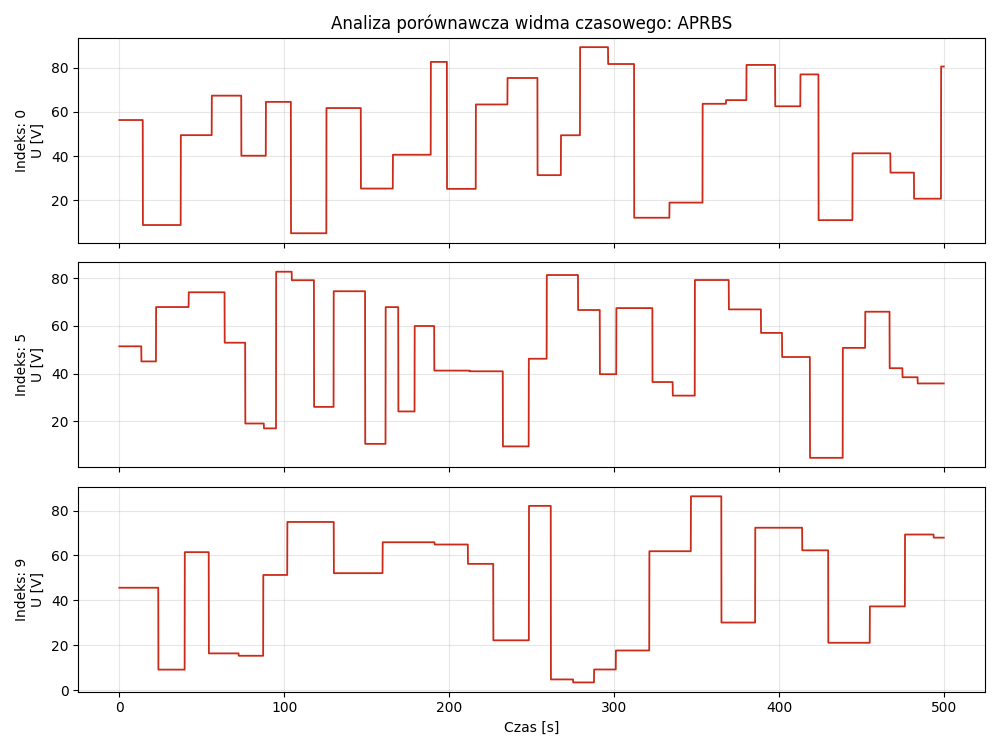

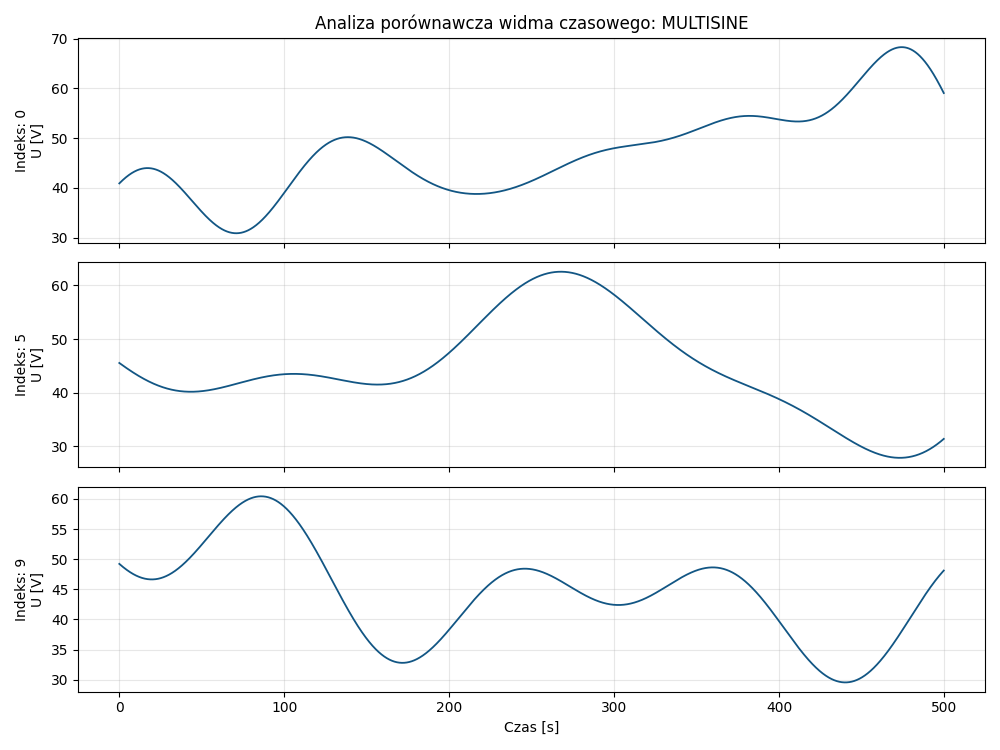

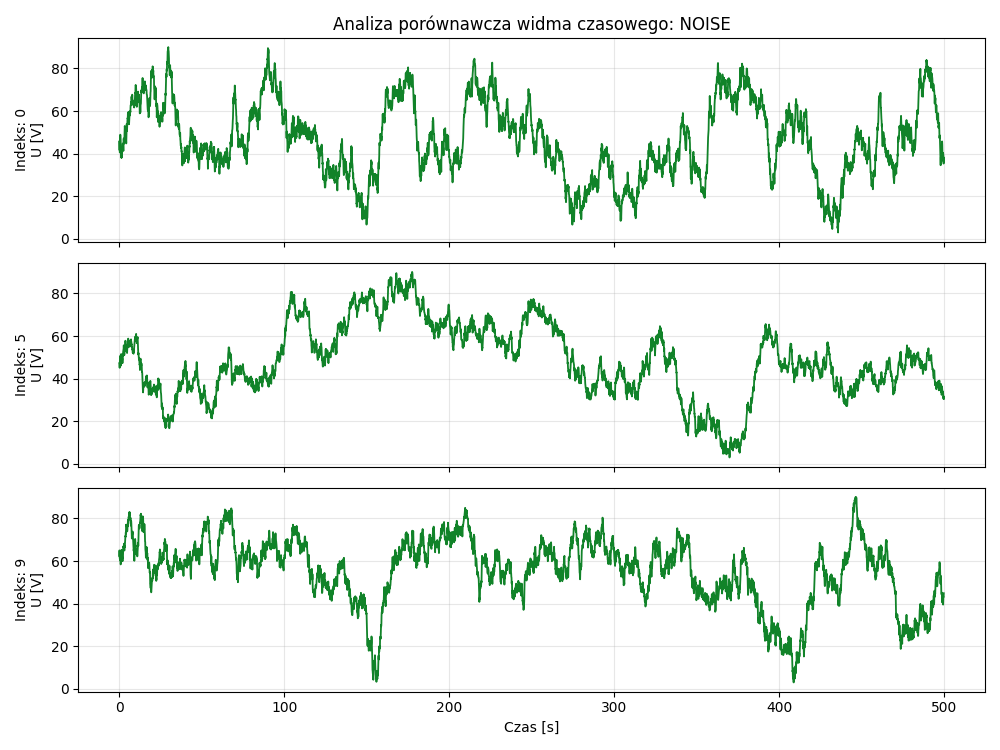

In [3]:
creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(3, 90), noise_level=0.0)
dataset = creator.create_dataset(n_aprbs=10, n_multisine=10, n_noise=10)

for category, signals in dataset.items():
    print(f"\n=== Kategoria: {category.upper()} ===")
    for i, traj in enumerate(signals[:1]):  
        print(f"Trajektoria nr {i+1}:")
        print(f"  t (pierwsze 5): {traj.t[:5]}")
        print(f"  y (pierwsze 5): {traj.y[:5]}")
        print(f"  Długość wektora: {len(traj.y)} próbek")
        print("-" * 30)

Plotter.plot_indices(dataset['aprbs'], "aprbs", indices=[0, 5, 9])

Plotter.plot_indices(dataset['multisine'], "multisine", indices=[0, 5, 9])

Plotter.plot_indices(dataset['noise'], "noise", indices=[0, 5, 9])

## FOURIER (DYSKRETNY)

Generowanie APRBS        :   0%|          | 0/10 [00:00<?, ?it/s]

Generowanie MULTISINE    :   0%|          | 0/10 [00:00<?, ?it/s]

Generowanie NOISE        :   0%|          | 0/10 [00:00<?, ?it/s]

Omega  (pierwsze 5): [28335.0864694    +0.j           257.47405617 +152.29889174j
 -1021.59485222 +478.27017584j  -205.37606836 +437.30215686j
   443.42163027-1644.83507821j]


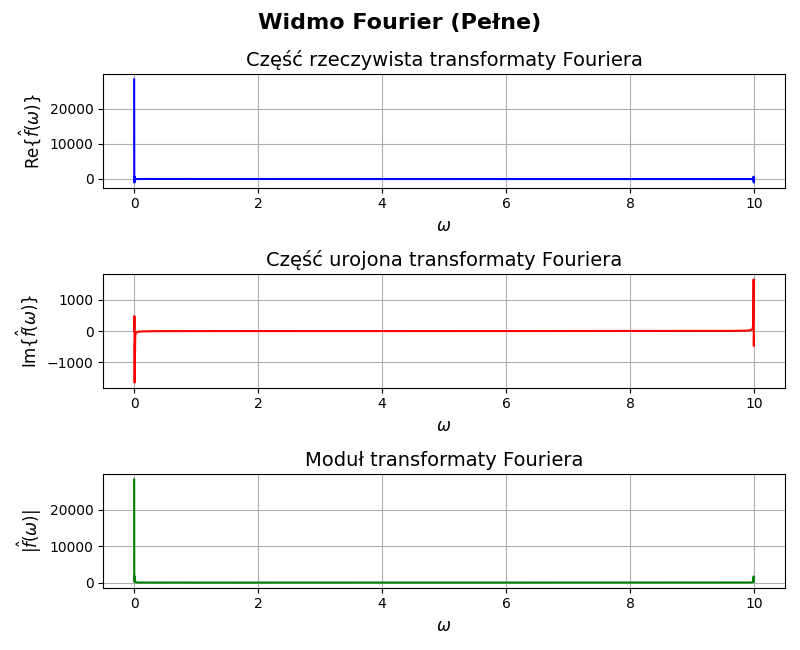

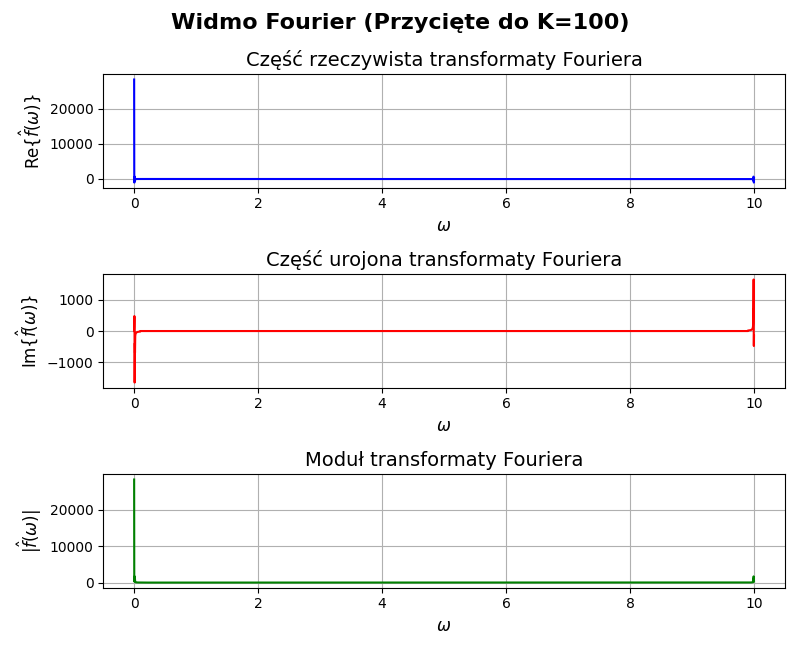

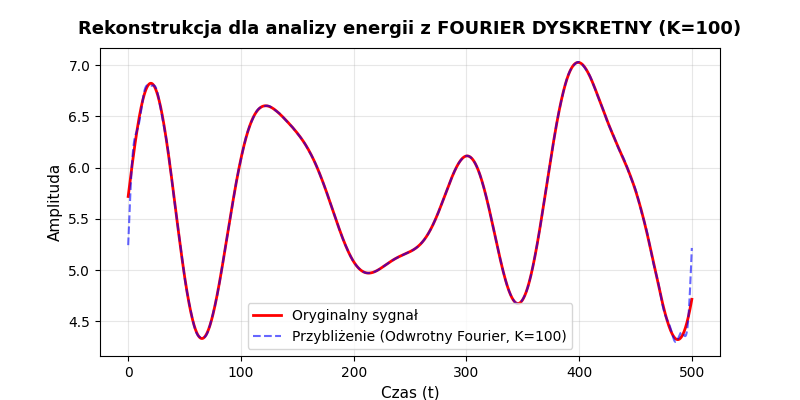

In [4]:
from DatasetCreator import DatasetCreator
from Fourier import DiscreteFourier
from Plotter import Plotter 

creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(3, 9), noise_level=0.0)
dataset = creator.create_dataset(n_aprbs=10, n_multisine=10, n_noise=10)

# sample_signal = dataset['aprbs'][0]  
sample_signal = dataset['multisine'][0]  

k=100  # Liczba współczynników do zachowania 

omega_vec, f_omega_vec = DiscreteFourier.transform(sample_signal.t, sample_signal.y)
print(f"Omega  (pierwsze 5): {f_omega_vec[:5]}")

f_trimmed = DiscreteFourier.trim_spectrum(f_omega_vec=f_omega_vec, k=k)

y_reconstructed = DiscreteFourier.inverse_transform(f_trimmed)

Plotter.plot_fourier_transform(omega_vec, f_omega_vec, title="Widmo Fourier (Pełne)")
Plotter.plot_fourier_transform(omega_vec, f_trimmed, title=f"Widmo Fourier (Przycięte do K={k})")

# Oryginał vs Rekonstrukcja
Plotter.plot_fourier_comparison(
    sample_signal.t, 
    sample_signal.y, 
    y_reconstructed, 
    K=k,
    title=f"Rekonstrukcja dla analizy energii z FOURIER DYSKRETNY (K={k})"
)


## FOURIER (NOWY)

Generowanie APRBS        :   0%|          | 0/10 [00:00<?, ?it/s]

Generowanie MULTISINE    :   0%|          | 0/10 [00:00<?, ?it/s]

Generowanie NOISE        :   0%|          | 0/10 [00:00<?, ?it/s]

--- Transformaty dla omega w zakresie [-5.0, 5.0] ---
Omega  (pierwsze 5): [-1.13230087+0.56965567j  0.08766077-0.21015326j  1.18938293+0.7374257j
  0.59929657+2.069135j   -0.84678014+1.88788732j]


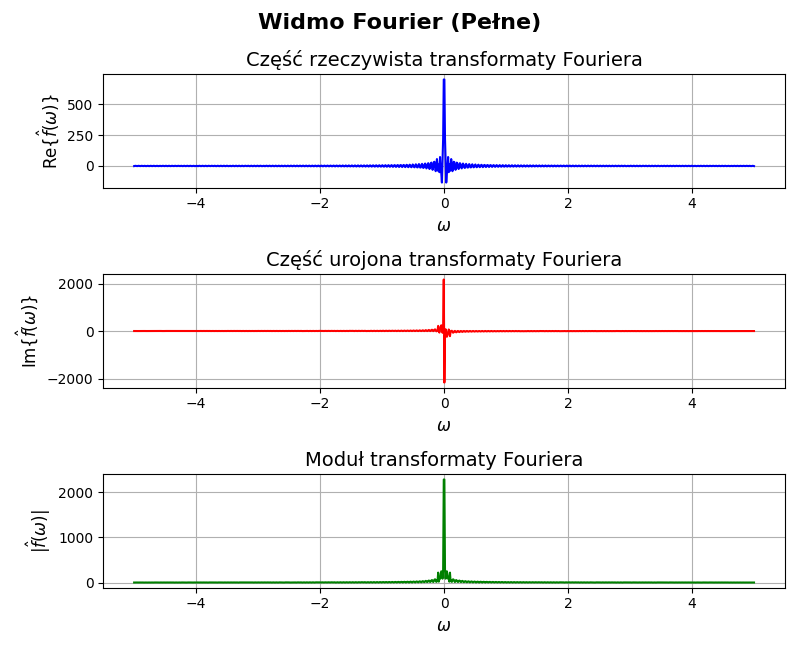

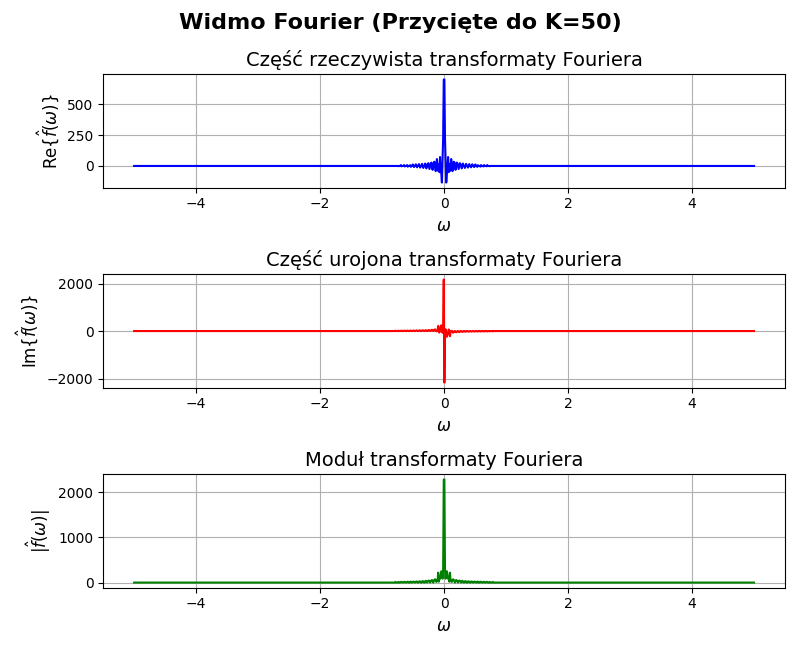

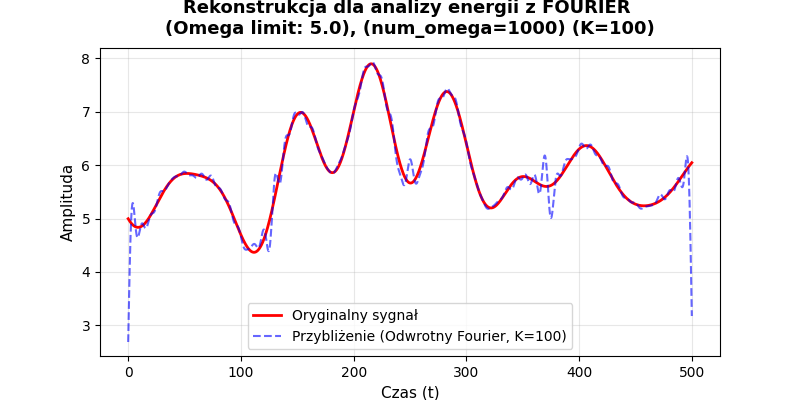

In [5]:
# 1. Generujemy dane
creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(3, 9), noise_level=0.0)
dataset = creator.create_dataset(n_aprbs=10, n_multisine=10, n_noise=10)

# sample_signal = dataset['aprbs'][0]  # Pobieramy pierwszy sygnał z kategorii APRBS
sample_signal = dataset['multisine'][0]  # Pobieramy pierwszy sygnał z kategorii MULTISINE


# 2. Inicjalizacja klasy Fourier
fourier_engine = Fourier(sample_signal.t, sample_signal.y)

# Parametry analizy
omega_limit = 5.0  # Zakres częstotliwości do analizy
num_omega = 1000  # Liczba punktów w zakresie omega - Używamy mniejszego num_omega dla szybkości lub większego dla precyzji
k=100  # Liczba współczynników do zachowania (przycinanie)

print(f"--- Transformaty dla omega w zakresie [-{omega_limit}, {omega_limit}] ---")

# 3. Obliczenie transformaty prostej dla zakresu częstotliwości
omega_vec, f_omega_vec = fourier_engine.transform(omega_limit=omega_limit, num_omega=num_omega)
print(f"Omega  (pierwsze 5): {f_omega_vec[:5]}")

# 4. Przycinamy do 50 najważniejszych współczynników (K=50)
f_trimmed = fourier_engine.trim_spectrum(omega_vec=omega_vec, f_omega_vec=f_omega_vec, k=k)

# 4. Obliczenie transformaty odwrotnej (rekonstrukcja sygnału)
y_reconstructed = fourier_engine.inverse_transform(omega_vec, f_trimmed)

# 5. Wizualizacja wyników
# Wykres widma (Część rzeczywista, urojona i moduł)
Plotter.plot_fourier_transform(omega_vec, f_omega_vec, title="Widmo Fourier (Pełne)")
Plotter.plot_fourier_transform(omega_vec, f_trimmed, title="Widmo Fourier (Przycięte do K=50)")

# Wykres porównawczy (Oryginał vs Rekonstrukcja)
Plotter.plot_fourier_comparison(
    sample_signal.t, 
    sample_signal.y, 
    y_reconstructed, 
    K=k,
    title=f"Rekonstrukcja dla analizy energii z FOURIER \n(Omega limit: {omega_limit}), (num_omega={num_omega}) (K={k})"
)


## FOURIER (STARY)

Generowanie APRBS        :   0%|          | 0/10 [00:00<?, ?it/s]

Generowanie MULTISINE    :   0%|          | 0/10 [00:00<?, ?it/s]

Generowanie NOISE        :   0%|          | 0/10 [00:00<?, ?it/s]

--- Transformaty dla omega w zakresie [-5.0, 5.0] ---
Omega  (pierwsze 5): [-11.00393405 +6.46322136j  11.51212835 +7.92179929j
  -8.02573225+19.42397574j   1.80687236 -1.03852947j
   5.13176596+21.5946636j ]


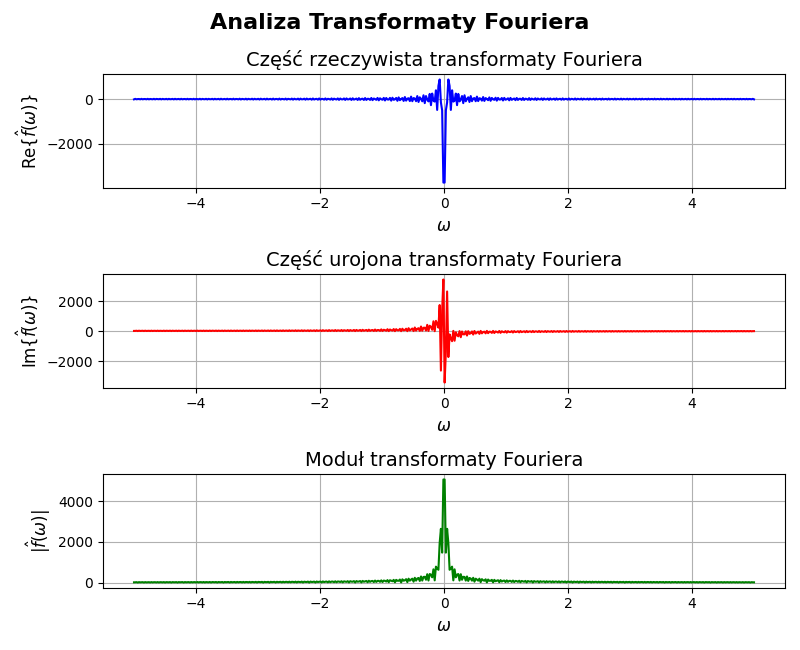

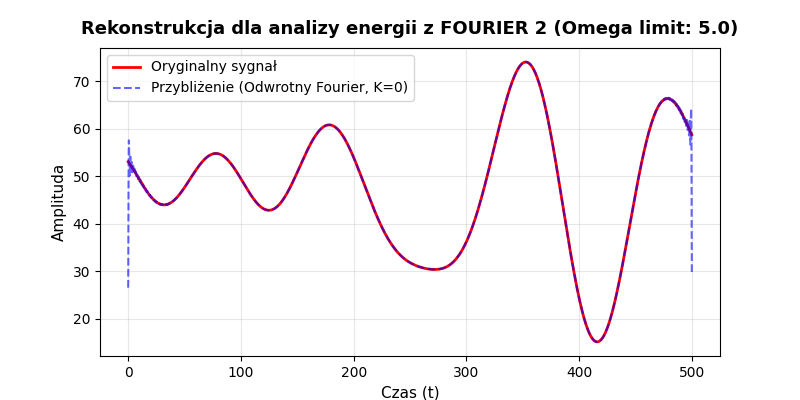

In [6]:
# 1. Generujemy dane
creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(3, 90), noise_level=0.0)
dataset = creator.create_dataset(n_aprbs=10, n_multisine=10, n_noise=10)

sample_signal = dataset['multisine'][0]  # Pobieramy pierwszy sygnał z kategorii MULTISINE

# 2. Inicjalizacja klasy Fourier
fourier_engine = Fourier2(sample_signal.t, sample_signal.y)

# 3. Obliczenie transformaty prostej dla zakresu częstotliwości
omega_limit = 5.0  # Zakres częstotliwości do analizy
omega_vec = np.linspace(-omega_limit, omega_limit, 500)
f_omega = fourier_engine.transform(omega_vec)

print(f"--- Transformaty dla omega w zakresie [-{omega_limit}, {omega_limit}] ---")
print(f"Omega  (pierwsze 5): {f_omega[:5]}")

# 4. Obliczenie transformaty odwrotnej (rekonstrukcja sygnału)
# Używamy mniejszego num_omega dla szybkości lub większego dla precyzji
y_reconstructed = fourier_engine.inverse_transform(
    omega_limit=omega_limit, 
    num_omega=1000
)

# 5. Wizualizacja wyników
# Wykres widma (Część rzeczywista, urojona i moduł)
Plotter.plot_fourier_transform(omega_vec, f_omega)

# Wykres porównawczy (Oryginał vs Rekonstrukcja)
Plotter.plot_fourier_comparison(
    sample_signal.t, 
    sample_signal.y, 
    y_reconstructed, 
    K=0,
    title=f"Rekonstrukcja dla analizy energii z FOURIER 2 (Omega limit: {omega_limit})"
)


## ANALIZA ENERGII

Generowanie APRBS        :   0%|          | 0/10 [00:00<?, ?it/s]

Generowanie MULTISINE    :   0%|          | 0/10 [00:00<?, ?it/s]

Generowanie NOISE        :   0%|          | 0/10 [00:00<?, ?it/s]


--- ANALIZA SYGNAŁU NOISE - NUMPY FFT ---
Energia w dziedzinie czasu: 159262.95
Wspołczynniki FFT - liczba: 5000...
Wspołczynniki FFT: [26998.24757392   +0.j          1306.90555006+1513.57736411j
 -1250.9888885  +107.79458437j  2216.6309818 -2228.59379666j
 -1256.98783395 +518.61113736j]...
Energia w dziedzinie częstotliwości: 159262.95
Liczba współczynników (K) dla 99.9% energii: 459


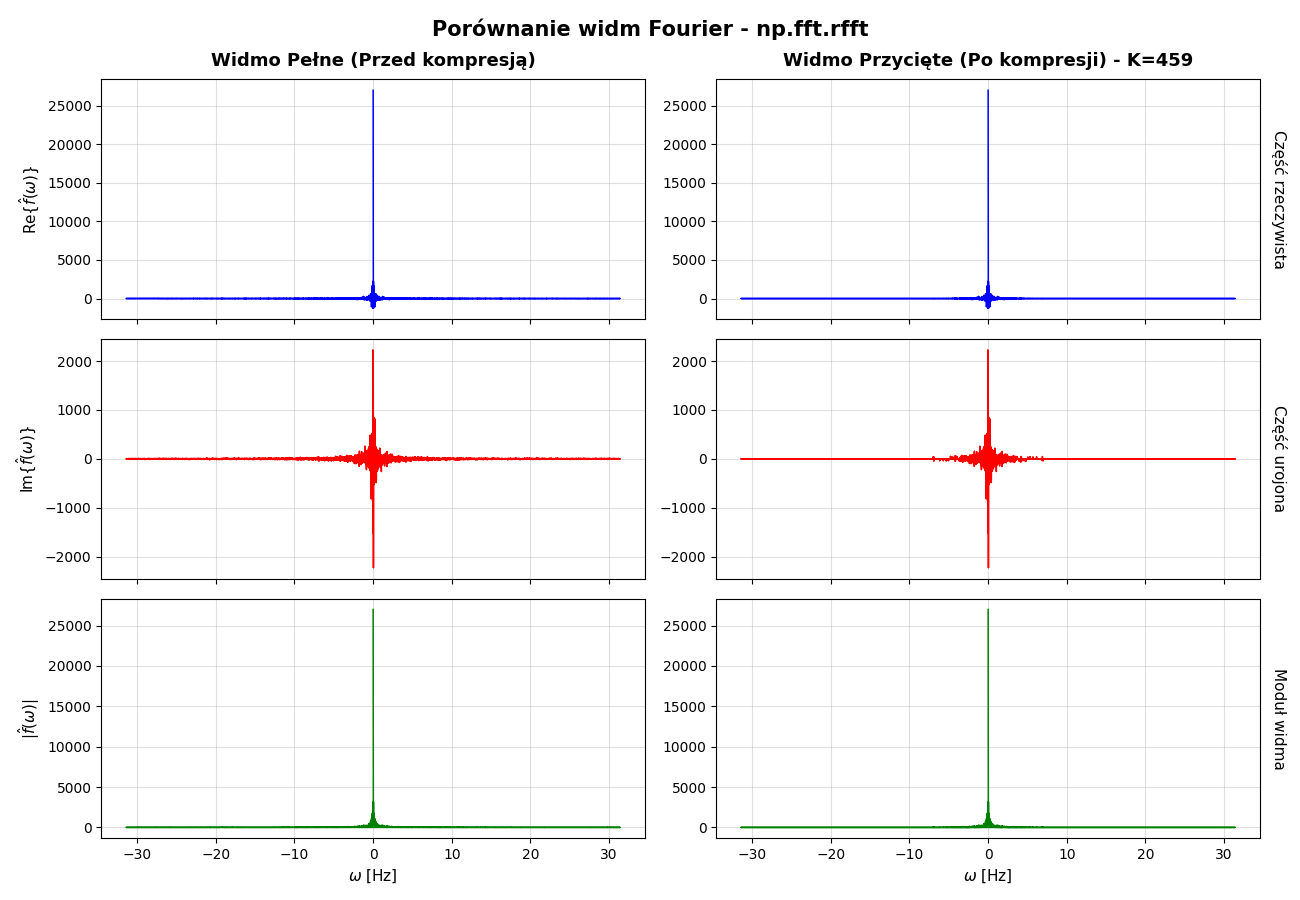

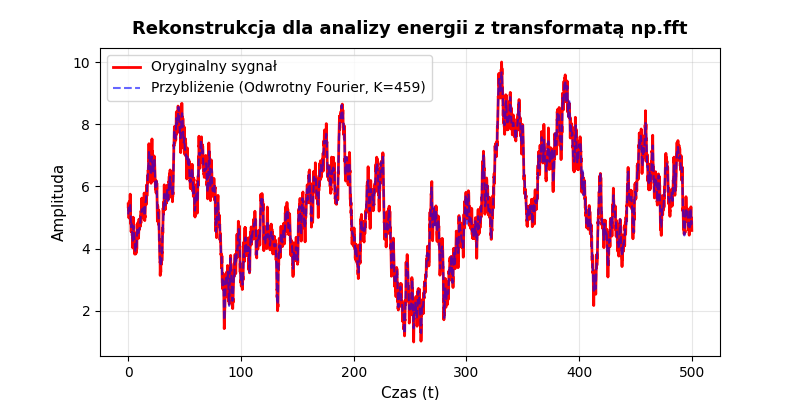


--- ANALIZA SYGNAŁU NOISE - WŁASNA FFT ---
Energia w dziedzinie czasu: 159262.95
Wspołczynniki FFT - liczba: 5000...
Wspołczynniki FFT: [26998.24757392   +0.j          1306.90555006+1513.57736411j
 -1250.9888885  +107.79458437j  2216.6309818 -2228.59379666j
 -1256.98783395 +518.61113736j]...
Energia w dziedzinie częstotliwości: 159262.95
Liczba współczynników (K) dla 99.9% energii: 459


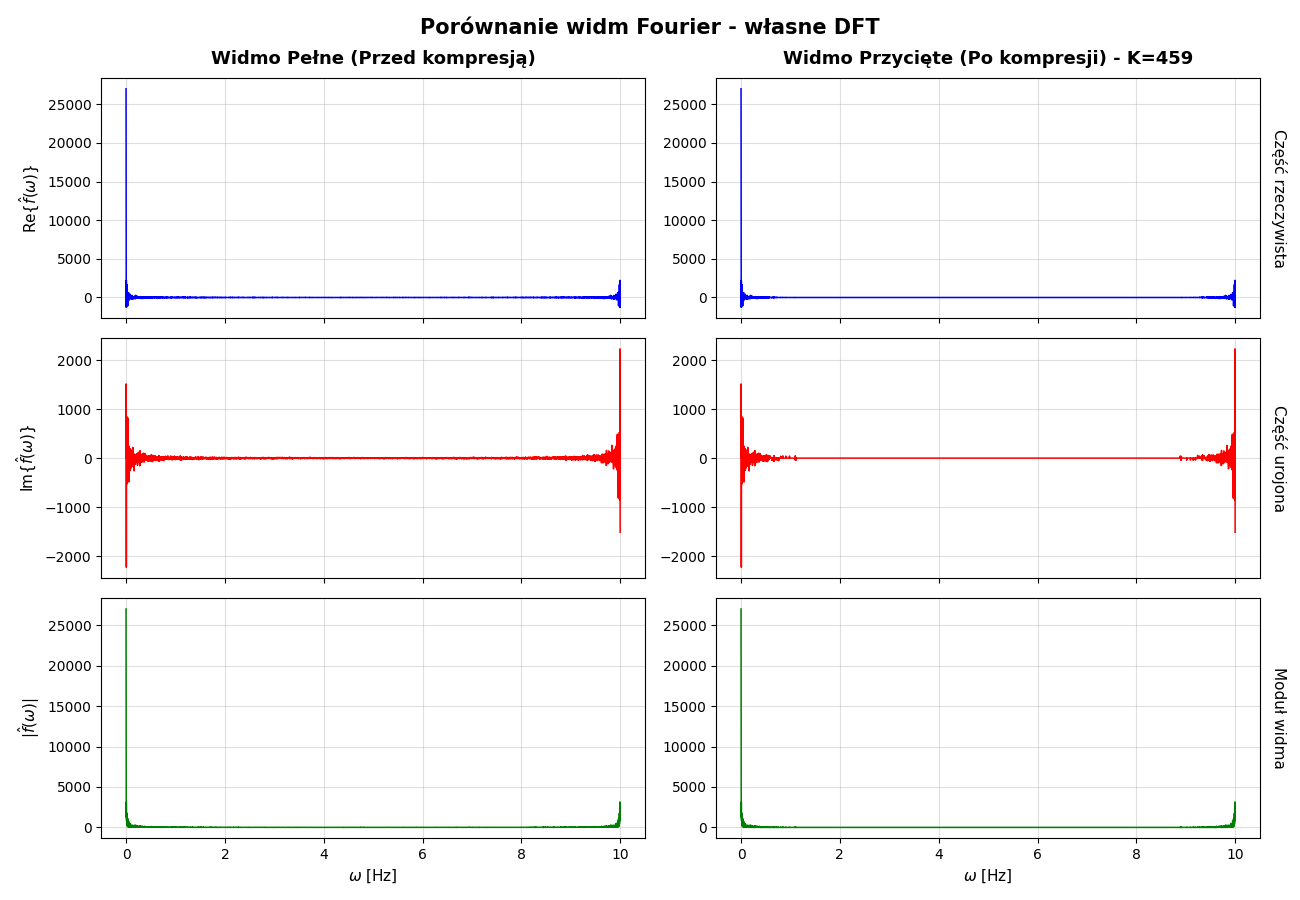

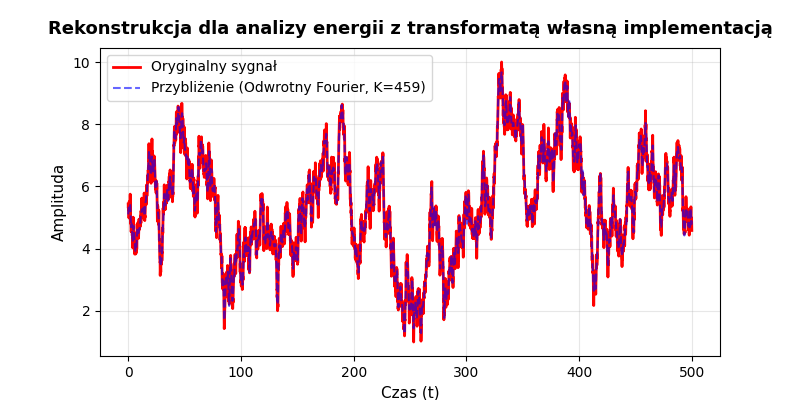

In [10]:
creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(1, 10), noise_level=0.0)
dataset = creator.create_dataset(n_aprbs=10, n_multisine=10, n_noise=10)

energy_threshold = 0.999  # Procent energii do zachowania (np. 0.999 dla 99.9%)
signal_type = 'noise'  # Wybierz kategorię sygnału: 'aprbs', 'multisine', 'noise'

# Analiza energii dla NUMPY FFT
print("\n--- ANALIZA SYGNAŁU " + signal_type.upper() + " - NUMPY FFT ---")# Pobieramy pierwszy sygnał z listy
signal = dataset[signal_type][0] 

e_time = EnergyAnalyzer.calculate_total_energy(signal.y)
print(f"Energia w dziedzinie czasu: {e_time:.2f}")

f_omega_numpy = np.fft.fft(signal.y)
freqs = np.fft.fftfreq(len(signal.y), d=(signal.t[1] - signal.t[0]))
omega_numpy = 2 * np.pi * freqs

results = EnergyAnalyzer.analyze_energy_distribution(f_omega_numpy, N=len(signal.y), threshold=energy_threshold)
print(f"Wspołczynniki FFT - liczba: {len(f_omega_numpy)}...")  # Pokazujemy tylko pierwsze 5 współczynników
print(f"Wspołczynniki FFT: {f_omega_numpy[:5]}...")  # Pokazujemy tylko pierwsze 5 współczynników
print(f"Energia w dziedzinie częstotliwości: {results['total_energy_freq']:.2f}")
print(f"Liczba współczynników (K) dla {energy_threshold*100}% energii: {results['k_threshold']}")

magnitudes = np.abs(f_omega_numpy)
threshold_val = np.sort(magnitudes)[-results['k_threshold']]
f_trimmed = np.where(magnitudes >= threshold_val, f_omega_numpy, 0)

y_reconstructed_np = np.fft.ifft(f_trimmed, n=len(signal.y))

Plotter.plot_fourier_comparison_widma(omega_numpy, f_omega_numpy, f_trimmed, K=results['k_threshold'], title="Porównanie widm Fourier - np.fft.rfft")

Plotter.plot_fourier_comparison(
    signal.t, 
    signal.y, 
    y_reconstructed_np, 
    K=results['k_threshold'],
    title=f"Rekonstrukcja dla analizy energii z transformatą np.fft"
)

# Analiza energii dla WŁASNEGO FFT
print("\n--- ANALIZA SYGNAŁU " + signal_type.upper() + " - WŁASNA FFT ---")# Pobieramy pierwszy sygnał z listy
signal = dataset[signal_type][0] 

e_time = EnergyAnalyzer.calculate_total_energy(signal.y)
print(f"Energia w dziedzinie czasu: {e_time:.2f}")

omega_vec, f_omega_vec = DiscreteFourier.transform(signal.t, signal.y)

results_dsc = EnergyAnalyzer.analyze_energy_distribution(f_omega_vec, N=len(signal.y), threshold=energy_threshold)
print(f"Wspołczynniki FFT - liczba: {len(f_omega_vec)}...")  # Pokazujemy tylko pierwsze 5 współczynników
print(f"Wspołczynniki FFT: {f_omega_vec[:5]}...")  # Pokazujemy tylko pierwsze 5 współczynników
print(f"Energia w dziedzinie częstotliwości: {results_dsc['total_energy_freq']:.2f}")
print(f"Liczba współczynników (K) dla {energy_threshold*100}% energii: {results_dsc['k_threshold']}")

f_trimmed = DiscreteFourier.trim_spectrum(f_omega_vec=f_omega_vec, k=results_dsc['k_threshold'])
y_reconstructed = DiscreteFourier.inverse_transform(f_trimmed)

Plotter.plot_fourier_comparison_widma(omega_vec, f_omega_vec, f_trimmed, K=results['k_threshold'], title="Porównanie widm Fourier - własne DFT")

Plotter.plot_fourier_comparison(
    signal.t, 
    signal.y, 
    y_reconstructed, 
    K=results_dsc['k_threshold'],
    title=f"Rekonstrukcja dla analizy energii z transformatą własną implementacją"
)

## ANALIZA DOKŁADNOŚCI

Generowanie APRBS        :   0%|          | 0/10 [00:00<?, ?it/s]

Generowanie MULTISINE    :   0%|          | 0/10 [00:00<?, ?it/s]

Generowanie NOISE        :   0%|          | 0/10 [00:00<?, ?it/s]


--- ANALIZA SYGNAŁU MULTISINE ---
Aby błąd maksymalny był < 2.0, potrzeba K = 124


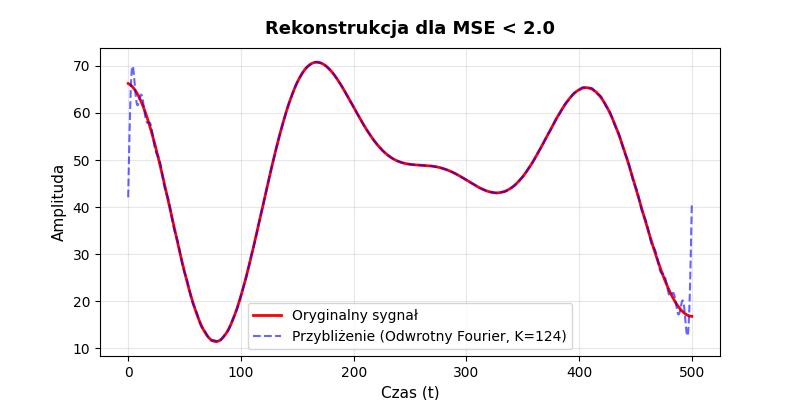

In [8]:
creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(3, 90), noise_level=0.0)
dataset = creator.create_dataset(n_aprbs=10, n_multisine=10, n_noise=10)

print("\n--- ANALIZA SYGNAŁU MULTISINE ---")
signal = dataset['multisine'][0] 

coeffs = np.fft.fft(signal.y)

max_allowed_diff = 2.0 
mode = 'mse'  #'max_error' jeśli  maksymalny błąd zamiast MSE
results = FidelityAnalyzer.analyze_by_error(signal.y, coeffs, threshold=max_allowed_diff, mode=mode)

print(f"Aby błąd maksymalny był < {max_allowed_diff}, potrzeba K = {results['k_threshold']}")

Plotter.plot_fourier_comparison(
    signal.t, 
    signal.y, 
    results['reconstructed_y'], 
    K=results['k_threshold'],
    title=f"Rekonstrukcja dla {mode.upper()} < {max_allowed_diff}"
)

## TESTY

In [9]:
creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(3, 90), noise_level=0.0)
big_dataset = creator.create_dataset(n_aprbs=5, n_multisine=5, n_noise=5)

tester = FidelityTester(big_dataset)

# Testy z naszą transformatą są długie (około 10 min)
stats = tester.run(threshold=3.0, mode='max_error', use_custom_fft=True)

print("--- RAPORT KOSZTU REPREZENTACJI (K) ---")
print(tester.display_results())

Generowanie APRBS        :   0%|          | 0/5 [00:00<?, ?it/s]

Generowanie MULTISINE    :   0%|          | 0/5 [00:00<?, ?it/s]

Generowanie NOISE        :   0%|          | 0/5 [00:00<?, ?it/s]

TypeError: FidelityTester.run() got an unexpected keyword argument 'threshold'

## OUTDATED

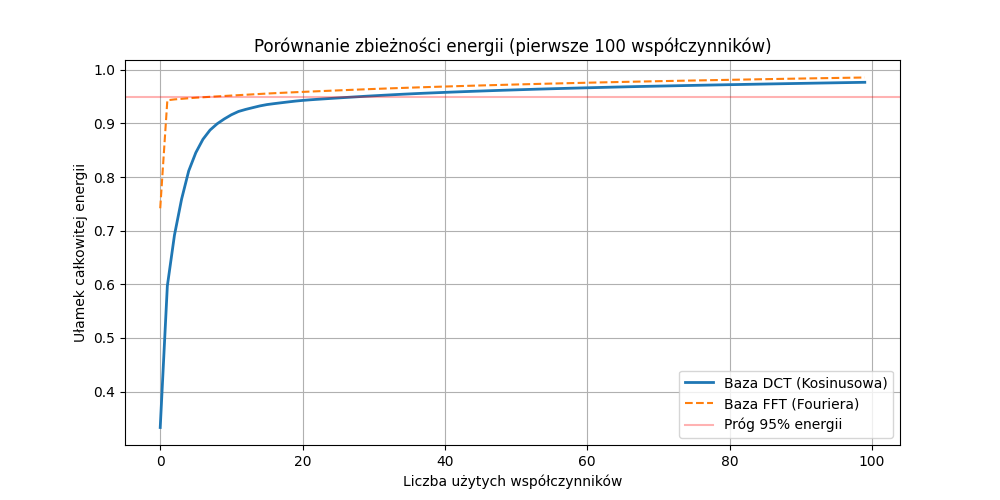

In [ ]:
import numpy as np
import scipy.fftpack as fftpack
import matplotlib.pyplot as plt

# 1. Tworzymy sygnał testowy (suma sinusów - model prostego dźwięku)
N = 512
t = np.linspace(0, 1, N)
signal = np.sin(2 * np.pi * 5 * t) + 0.5 * np.sin(2 * np.pi * 20 * t) + 0.2 * np.random.randn(N)

# 2. Obliczamy współczynniki w dwóch bazach
# FFT (Fourier) - bierzemy moduł, bo FFT daje liczby zespolone
coef_fft = np.abs(np.fft.rfft(signal)) 
# DCT (Kosinusowa) - standard w audio
coef_dct = np.abs(fftpack.dct(signal, norm='ortho'))

# 3. Funkcja do obliczania skumulowanej energii (zbieżności)
def get_energy_convergence(coeffs):
    # Sortujemy współczynniki od największego (najważniejszego) do najmniejszego
    sorted_coeffs = np.sort(np.abs(coeffs))[::-1]
    # Liczymy sumę skumulowaną kwadratów (energia to kwadrat amplitudy)
    energy_cumulative = np.cumsum(sorted_coeffs**2)
    # Normalizujemy do 1.0 (czyli do 100%)
    return energy_cumulative / energy_cumulative[-1]

# 4. Obliczamy krzywe zbieżności
energy_fft = get_energy_convergence(coef_fft)
energy_dct = get_energy_convergence(coef_dct)

# 5. Wykres porównawczy
plt.figure(figsize=(10, 5))
plt.plot(energy_dct[:100], label='Baza DCT (Kosinusowa)', linewidth=2)
plt.plot(energy_fft[:100], label='Baza FFT (Fouriera)', linestyle='--')
plt.axhline(y=0.95, color='r', alpha=0.3, label='Próg 95% energii')
plt.title("Porównanie zbieżności energii (pierwsze 100 współczynników)")
plt.xlabel("Liczba użytych współczynników")
plt.ylabel("Ułamek całkowitej energii")
plt.legend()
plt.grid(True)
plt.show()

# Kompresja .wav

C:\Users\janga\AppData\Local\Temp\ipykernel_8520\1989784917.py:12: WavFileWarning: Chunk (non-data) not understood, skipping it.
  rate, data = wav.read(source_path)
C:\Users\janga\AppData\Local\Temp\ipykernel_8520\1989784917.py:22: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 4))


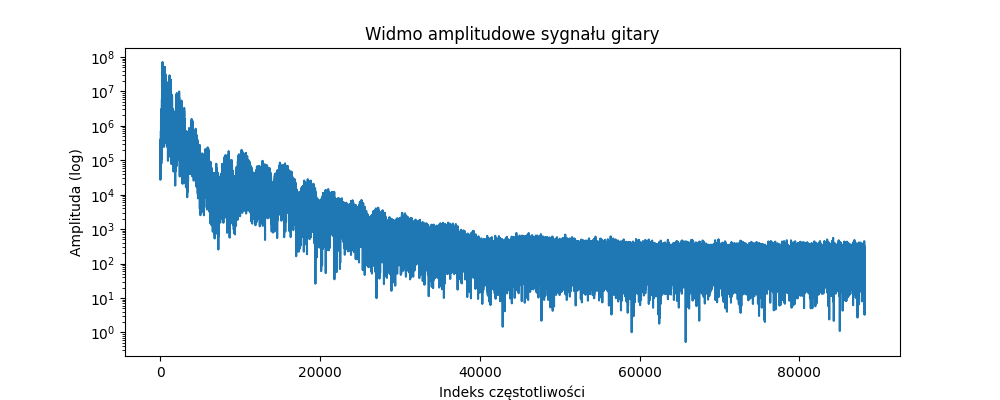

Plik zapisano jako: data/compressed/wynik_cr_0.1_d_07_06_2026_13_35.wav
--- ANALIZA ROZMIARU PLIKÓW ---
Rozmiar oryginału:   690.88 KB
Rozmiar po kompresji: 344.57 KB
Redukcja miejsca:     50.13%
Oryginalny sygnał:


Skompresowany sygnał (po FFT) - compression ratio: 0.1:


In [11]:
import scipy.io.wavfile as wav
import os
import datetime
from IPython.display import Audio, display

# 1. Ścieżki do katalogów
input_dir = 'data/source'
output_dir = 'data/compressed'

# 2: Ładowanie pliku
source_path = f'{input_dir}/gitara_strun_ma_wiele.wav'
rate, data = wav.read(source_path)

if len(data.shape) > 1:
    data = data.mean(axis=1)
data = data.astype(float)

# 3: Analiza przed kompresją (wizualizacja)
coeffs = np.fft.rfft(data)
amplitudes = np.abs(coeffs)

plt.figure(figsize=(10, 4))
plt.semilogy(amplitudes) # Skala logarytmiczna lepiej pokazuje rozkład energii
plt.title("Widmo amplitudowe sygnału gitary")
plt.xlabel("Indeks częstotliwości")
plt.ylabel("Amplituda (log)")
plt.show()

# 4: Kompresja i zapis
compression_ratio = 0.1  # 10%
threshold = np.percentile(amplitudes, (1 - compression_ratio) * 100)

coeffs_compressed = coeffs.copy()
coeffs_compressed[amplitudes < threshold] = 0

compressed_data = np.int16(np.fft.irfft(coeffs_compressed))

# Zapis
os.makedirs(output_dir, exist_ok=True) # exist_ok=True zastępuje if not os.path.exists

date_str = datetime.datetime.now().strftime('%d_%m_%Y_%H_%M')
compressed_path = f"{output_dir}/wynik_cr_{compression_ratio}_d_{date_str}.wav"

wav.write(compressed_path, rate, compressed_data)
print(f"Plik zapisano jako: {compressed_path}")

def get_file_size_kb(path):
    # Pobiera rozmiar w bajtach i dzieli przez 1024, aby dostać KB
    return os.path.getsize(path) / 1024

# Sprawdzenie rozmiarów
size_orig = get_file_size_kb(source_path)
size_comp = get_file_size_kb(compressed_path)
ratio = (1 - (size_comp / size_orig)) * 100

print(f"--- ANALIZA ROZMIARU PLIKÓW ---")
print(f"Rozmiar oryginału:   {size_orig:.2f} KB")
print(f"Rozmiar po kompresji: {size_comp:.2f} KB")
print(f"Redukcja miejsca:     {ratio:.2f}%")

# 5: Odtwarzanie w notebooku
print("Oryginalny sygnał:")
display(Audio(data, rate=rate))

print(f"Skompresowany sygnał (po FFT) - compression ratio: {compression_ratio}:")
display(Audio(compressed_data, rate=rate))

# Kompresja .wav -> .kmp

In [12]:
import struct

# --- 1. KODER (WAV -> KMP) ---
def koder_wav_do_kmp(wav_path, kmp_path, ratio):
    # Wczytanie surowego WAV
    rate, data = wav.read(wav_path)
    
    # Jeśli stereo, miksujemy do mono
    if len(data.shape) > 1:
        data = data.mean(axis=1)
        
    # KLUCZOWE: Konwersja int16 -> float32 w zakresie [-1.0, 1.0]
    # Bez tego normalizowania FFT dostaje bzika i generuje szum
    data_float = data.astype(np.float32) / 32768.0
    
    # Wykonanie FFT - NUMPY FFT
    coeffs = np.fft.rfft(data_float)

    # # Wykonanie FFT - WŁASNA IMPLEMENTACJA
    # fourier_engine = DiscreteFourier(rate, data)
    # coeffs = fourier_engine.transform()

    # Amplitudy współczynników (moduł) - potrzebne do wyznaczenia progu odcięcia
    amplitudes = np.abs(coeffs)
    
    # Wyznaczenie progu odcięcia (bierzemy X% największych amplitud)
    threshold = np.percentile(amplitudes, (1 - ratio) * 100)
    
    # Znalezienie indeksów współczynników, które przetrwały kompresję
    indices = np.where(amplitudes >= threshold)[0].astype(np.int32)
    
    # Wyciągnięcie tylko tych ważnych współczynników (część rzeczywista i urojona osobnym float32)
    filtered_real = np.real(coeffs[indices]).astype(np.float32)
    filtered_imag = np.imag(coeffs[indices]).astype(np.float32)
    
    # Zapis do czystego pliku binarnego .kmp
    with open(kmp_path, 'wb') as f:
        # Nagłówek: 1. Długość sygnału (int), 2. Liczba indeksów (int), 3. Próbkowanie (int)
        f.write(struct.pack('iii', len(data_float), len(indices), rate))
        # Dane właściwe
        f.write(indices.tobytes())
        f.write(filtered_real.tobytes())
        f.write(filtered_imag.tobytes())
        
    print(f"[KODER] Sukces! Skompresowano {wav_path} -> {kmp_path}")


# --- 2. DEKODER (KMP -> WAV) ---
def dekoder_kmp_do_wav(kmp_path, output_wav_path):
    with open(kmp_path, 'rb') as f:
        # Odczyt nagłówka (3 x int = 12 bajtów)
        total_len, num_indices, rate = struct.unpack('iii', f.read(12))
        
        # Odczyt tablic binarnych
        indices = np.frombuffer(f.read(num_indices * 4), dtype=np.int32)
        filtered_real = np.frombuffer(f.read(num_indices * 4), dtype=np.float32)
        filtered_imag = np.frombuffer(f.read(num_indices * 4), dtype=np.float32)
        
    # Tworzenie pustego widma dla rfft: rozmiar to zawsze (N // 2) + 1
    num_coeffs = (total_len // 2) + 1
    coeffs_rec = np.zeros(num_coeffs, dtype=complex)
    
    # Odtworzenie liczb zespolonych na zakodowanych pozycjach
    coeffs_rec[indices] = filtered_real + 1j * filtered_imag
    
    # Odwrotna transformata (powrót do dźwięku w czasie)
    data_rec_float = np.fft.irfft(coeffs_rec, n=total_len)
    
    # fourier_engine = DiscreteFourier(rate, data)
    # coeffs = fourier_engine.transform()
    
    # Zabezpieczenie przed przesterowaniem (clipping)
    data_rec_float = np.clip(data_rec_float, -1.0, 1.0)
    
    # Powrót do formatu int16 dla klasycznego pliku WAV
    final_wav_data = (data_rec_float * 32767.0).astype(np.int16)
    
    # Zapis finalnego pliku na dysk
    wav.write(output_wav_path, rate, final_wav_data)
    print(f"[DEKODER] Sukces! Zrekonstruowano {kmp_path} -> {output_wav_path}")
    return final_wav_data, rate

C:\Users\janga\AppData\Local\Temp\ipykernel_8520\2392458493.py:32: WavFileWarning: Chunk (non-data) not understood, skipping it.
  rate_orig, data_orig = wav.read(source_wav_path)
C:\Users\janga\AppData\Local\Temp\ipykernel_8520\3633205549.py:6: WavFileWarning: Chunk (non-data) not understood, skipping it.
  rate, data = wav.read(wav_path)


--- ROZPOCZĘCIE AUTOMATYCZNEJ ANALIZY ---
[KODER] Sukces! Skompresowano data/source/gitara_strun_ma_wiele.wav -> data/compressed_2/compressed_ratio_0.01.kmp
[DEKODER] Sukces! Zrekonstruowano data/compressed_2/compressed_ratio_0.01.kmp -> data/compressed_2/compressed_ratio_0.01_decoded.wav
Ratio 1.0% -> KMP: 10.36 KB, MSE: 0.000238, Entropia: 6.1478

[KODER] Sukces! Skompresowano data/source/gitara_strun_ma_wiele.wav -> data/compressed_2/compressed_ratio_0.05.kmp
[DEKODER] Sukces! Zrekonstruowano data/compressed_2/compressed_ratio_0.05.kmp -> data/compressed_2/compressed_ratio_0.05_decoded.wav
Ratio 5.0% -> KMP: 51.70 KB, MSE: 0.000002, Entropia: 5.9948

[KODER] Sukces! Skompresowano data/source/gitara_strun_ma_wiele.wav -> data/compressed_2/compressed_ratio_0.1.kmp
[DEKODER] Sukces! Zrekonstruowano data/compressed_2/compressed_ratio_0.1.kmp -> data/compressed_2/compressed_ratio_0.1_decoded.wav
Ratio 10.0% -> KMP: 103.38 KB, MSE: 0.000000, Entropia: 5.9853

[KODER] Sukces! Skompresowano

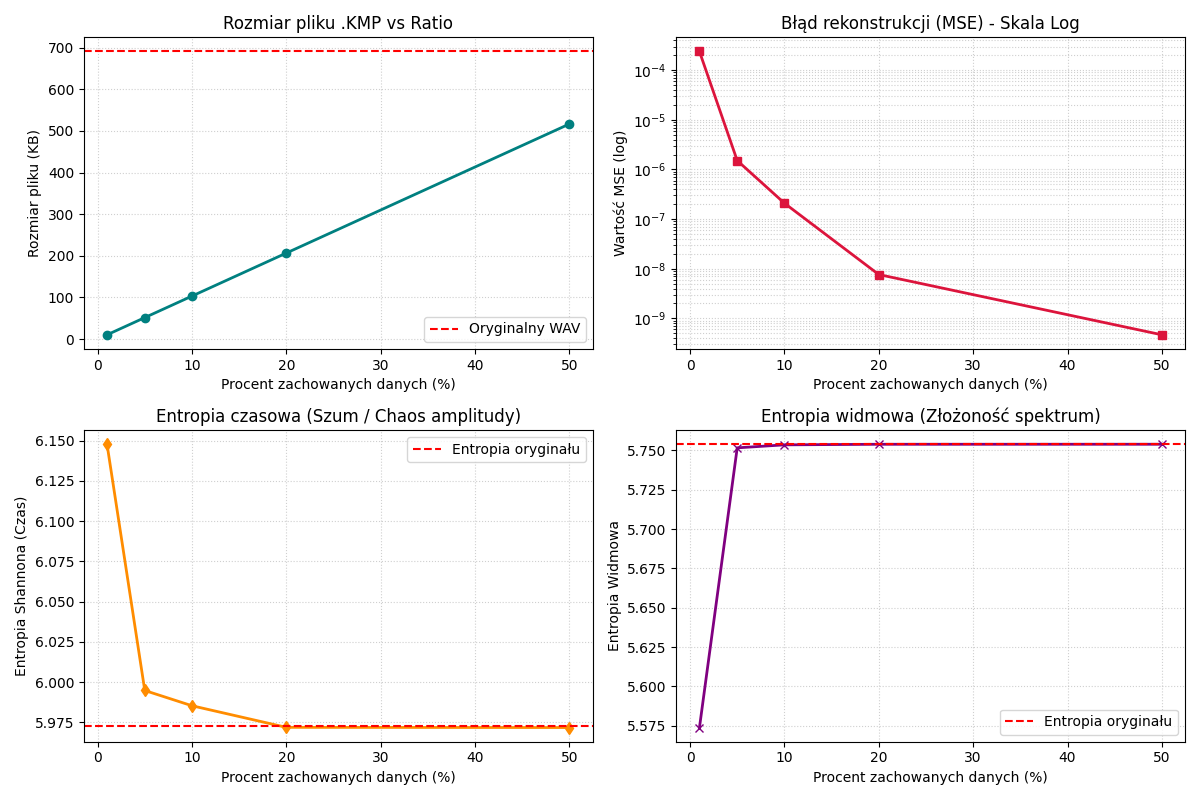


             PANEL ODSŁUCHU PORÓWNAWCZEGO

[REFERENCE] ORYGINALNY SYGNAŁ (WAV):


--------------------------------------------------

Sygnał skompresowany: 1.0% danych (Rozmiar: 10.36 KB | Redukcja: 98.50%)



Sygnał skompresowany: 5.0% danych (Rozmiar: 51.70 KB | Redukcja: 92.52%)



Sygnał skompresowany: 10.0% danych (Rozmiar: 103.38 KB | Redukcja: 85.04%)



Sygnał skompresowany: 20.0% danych (Rozmiar: 206.74 KB | Redukcja: 70.08%)



Sygnał skompresowany: 50.0% danych (Rozmiar: 516.82 KB | Redukcja: 25.19%)


In [14]:
import numpy as np
import os
import shutil
from IPython.display import Audio, display
import scipy.io.wavfile as wav
from scipy.stats import entropy 

# --- 1. KONFIGURACJA ---
input_dir = 'data/source'
output_dir = 'data/compressed_2'

if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
os.makedirs(output_dir)

# Ścieżka do pliku wejściowego WAV
source_name = 'gitara_strun_ma_wiele'
# source_name = 'surprise'
source_wav_path = f'{input_dir}/{source_name}.wav'


# Lista progów kompresji do sprawdzenia
ratios_to_test = [0.01, 0.05, 0.10, 0.20, 0.50]

results_size = []
results_mse = []
results_entropy = []
results_entropy_widmowa = []
audio_clips = {} # Słownik na odkodowane próbki do późniejszego odsłuchu

# Wczytujemy oryginał raz do obliczenia MSE i dla odsłuchu
rate_orig, data_orig = wav.read(source_wav_path)
if len(data_orig.shape) > 1:
    data_orig = data_orig.mean(axis=1)
data_orig_float = data_orig.astype(np.float32) / 32768.0

# Funkcja pomocnicza do liczenia entropii sygnału audio
def oblicz_entropie_sygnalu(signal_float, bins=1024):
    # Tworzymy histogram rozkładu amplitud
    hist, _ = np.histogram(signal_float, bins=bins, density=True)
    # Dodajemy małą wartość (1e-12), żeby uniknąć log(0) w obliczeniach
    hist = hist + 1e-12
    return entropy(hist)

def oblicz_entropie_widmowa(signal_float):
    # 1. Liczymy FFT z sygnału (w czasie)
    fft_vals = np.fft.rfft(signal_float)
    
    # 2. Liczymy gęstość mocy (Power Spectral Density)
    psd = np.abs(fft_vals) ** 2
    
    # 3. Normalizujemy do rozkładu prawdopodobieństwa (suma musi być = 1)
    psd_norm = psd / np.sum(psd)
    
    # 4. Liczymy entropię Shannona z unormowanego widma
    return entropy(psd_norm)

orig_entropy = oblicz_entropie_sygnalu(data_orig_float)
orig_entropy_widmowa = oblicz_entropie_widmowa(data_orig_float)
size_orig_wav = os.path.getsize(source_wav_path) / 1024

print("--- ROZPOCZĘCIE AUTOMATYCZNEJ ANALIZY ---")

for ratio in ratios_to_test:
    test_kmp_path = f'{output_dir}/compressed_ratio_{ratio}.kmp'
    test_wav_path = f'{output_dir}/compressed_ratio_{ratio}_decoded.wav'
    
    # Koder -> Dekoder
    koder_wav_do_kmp(source_wav_path, test_kmp_path, ratio)
    decoded_data, sample_rate = dekoder_kmp_do_wav(test_kmp_path, test_wav_path)
    
    # Zapisujemy tablicę audio do słownika, żeby odtworzyć ją na końcu
    audio_clips[ratio] = decoded_data
    
    # Skalujemy zdekodowany int16 do float dla MSE
    decoded_float = decoded_data.astype(np.float32) / 32767.0
    
# Obliczenia metryk
    kmp_size_kb = os.path.getsize(test_kmp_path) / 1024
    mse_val = np.mean((data_orig_float - decoded_float) ** 2)
    entropy_val = oblicz_entropie_sygnalu(decoded_float) # <--- OBLICZANIE ENTROPII
    entropy_widmowa_val = oblicz_entropie_widmowa(decoded_float) # <--- OBLICZANIE ENTROPII WIDMOWEJ

    results_size.append(kmp_size_kb)
    results_mse.append(mse_val)
    results_entropy.append(entropy_val)
    results_entropy_widmowa.append(entropy_widmowa_val)
    
    print(f"Ratio {ratio*100}% -> KMP: {kmp_size_kb:.2f} KB, MSE: {mse_val:.6f}, Entropia: {entropy_val:.4f}\n")

# --- 3. GENEROWANIE 4 WYKRESÓW W UKŁADZIE 2x2 ---
fig, axs = plt.subplots(2, 2, figsize=(12, 8))  # Układ 2 wiersze, 2 kolumny

# Wykres 1 (Wiersz 0, Kolumna 0): Rozmiar pliku
axs[0, 0].plot(np.array(ratios_to_test) * 100, results_size, 'o-', color='teal', linewidth=2)
axs[0, 0].axhline(y=size_orig_wav, color='r', linestyle='--', label='Oryginalny WAV')
axs[0, 0].set_title("Rozmiar pliku .KMP vs Ratio")
axs[0, 0].set_xlabel("Procent zachowanych danych (%)")
axs[0, 0].set_ylabel("Rozmiar pliku (KB)")
axs[0, 0].grid(True, linestyle=':', alpha=0.6)
axs[0, 0].legend()

# Wykres 2 (Wiersz 0, Kolumna 1): Błąd MSE
axs[0, 1].plot(np.array(ratios_to_test) * 100, results_mse, 's-', color='crimson', linewidth=2)
axs[0, 1].set_yscale('log')
axs[0, 1].set_title("Błąd rekonstrukcji (MSE) - Skala Log")
axs[0, 1].set_xlabel("Procent zachowanych danych (%)")
axs[0, 1].set_ylabel("Wartość MSE (log)")
axs[0, 1].grid(True, which="both", linestyle=':', alpha=0.6)

# Wykres 3 (Wiersz 1, Kolumna 0): Entropia Czasowa (Rozkład amplitud)
axs[1, 0].plot(np.array(ratios_to_test) * 100, results_entropy, 'd-', color='darkorange', linewidth=2)
axs[1, 0].axhline(y=orig_entropy, color='r', linestyle='--', label='Entropia oryginału')
axs[1, 0].set_title("Entropia czasowa (Szum / Chaos amplitudy)")
axs[1, 0].set_xlabel("Procent zachowanych danych (%)")
axs[1, 0].set_ylabel("Entropia Shannona (Czas)")
axs[1, 0].grid(True, linestyle=':', alpha=0.6)
axs[1, 0].legend()

# Wykres 4 (Wiersz 1, Kolumna 1): Entropia Widmowa (Zawartość informacji)
axs[1, 1].plot(np.array(ratios_to_test) * 100, results_entropy_widmowa, 'x-', color='purple', linewidth=2)
axs[1, 1].axhline(y=orig_entropy_widmowa, color='r', linestyle='--', label='Entropia oryginału')
axs[1, 1].set_title("Entropia widmowa (Złożoność spektrum)")
axs[1, 1].set_xlabel("Procent zachowanych danych (%)")
axs[1, 1].set_ylabel("Entropia Widmowa")
axs[1, 1].grid(True, linestyle=':', alpha=0.6)
axs[1, 1].legend()

plt.tight_layout()
plt.savefig(f'{output_dir}/pelna_analiza_kompresji.png', dpi=300)
plt.show()

# --- SEKCO ODSŁUCHU PORÓWNAWCZEGO ---
print("\n" + "="*50)
print("             PANEL ODSŁUCHU PORÓWNAWCZEGO")
print("="*50)

print("\n[REFERENCE] ORYGINALNY SYGNAŁ (WAV):")
display(Audio(data_orig, rate=rate_orig))
print("-" * 50)

# Pętla generująca odtwarzacze dla każdego ratio
for ratio in ratios_to_test:
    percentage = ratio * 100
    kmp_size = os.path.getsize(f'{output_dir}/compressed_ratio_{ratio}.kmp') / 1024
    reduction = 100 * (1 - kmp_size / size_orig_wav)
    
    print(f"\nSygnał skompresowany: {percentage}% danych (Rozmiar: {kmp_size:.2f} KB | Redukcja: {reduction:.2f}%)")
    display(Audio(audio_clips[ratio], rate=sample_rate))